## 1. Imports & setup

In [3]:
import os

# Make sure the folder exists

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

FIG_DIR = "../reports/figures/"
os.makedirs(FIG_DIR, exist_ok=True)


## 2. load data

In [4]:
df = pd.read_csv(r"A:\HACKATHONE\Clean-Air-Climate-Resilience\data\raw\city_day.csv")
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


## 3. Basic Structure


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,24933.0,67.450578,64.661449,0.04,28.820,48.57,80.5900,949.99
PM10,18391.0,118.127103,90.605110,0.01,56.255,95.68,149.7450,1000.00
NO,25949.0,17.574730,22.785846,0.02,5.630,9.89,19.9500,390.68
NO2,25946.0,28.560659,24.474746,0.01,11.750,21.69,37.6200,362.21
NOx,25346.0,32.309123,31.646011,0.00,12.820,23.52,40.1275,467.63
NH3,19203.0,23.483476,25.684275,0.01,8.580,15.85,30.0200,352.89
CO,27472.0,2.248598,6.962884,0.00,0.510,0.89,1.4500,175.81
SO2,25677.0,14.531977,18.133775,0.01,5.670,9.16,15.2200,193.86
O3,25509.0,34.491430,21.694928,0.01,18.860,30.84,45.5700,257.73
Benzene,23908.0,3.280840,15.811136,0.00,0.120,1.07,3.0800,455.03


In [7]:
df.isnull().sum() / len(df) * 100

City           0.000000
Date           0.000000
PM2.5         15.570079
PM10          37.723071
NO            12.129626
NO2           12.139785
NOx           14.171549
NH3           34.973418
CO             6.972334
SO2           13.050692
O3            13.619586
Benzene       19.041008
Toluene       27.229014
Xylene        61.322001
AQI           15.851139
AQI_Bucket    15.851139
dtype: float64

In [8]:
df['City'].value_counts()

City
Ahmedabad             2009
Delhi                 2009
Mumbai                2009
Bengaluru             2009
Lucknow               2009
Chennai               2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Ernakulam              162
Kochi                  162
Aizawl                 113
Name: count, dtype: int64

In [9]:
df['AQI_Bucket'].value_counts()

AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64

## 4. Target value analysis

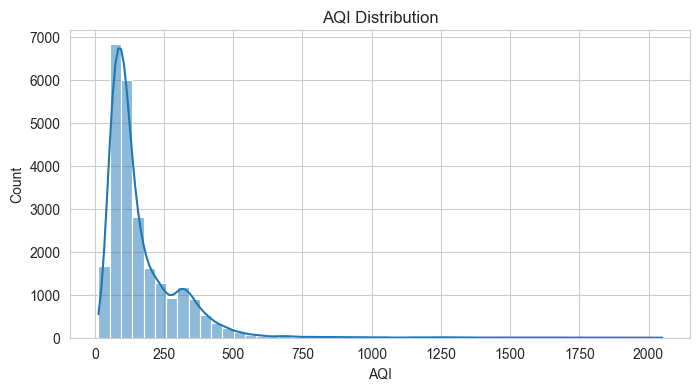

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df['AQI'].dropna(), bins=50, kde=True)
plt.title("AQI Distribution")
plt.xlabel("AQI")

# Now save the figure
plt.savefig(FIG_DIR + "aqi_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


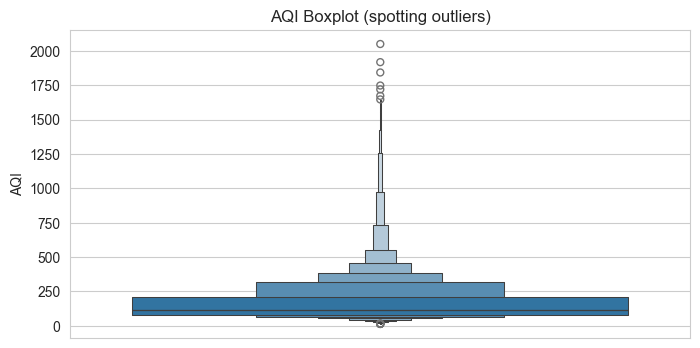

In [11]:
plt.figure(figsize=(8,4))
sns.boxenplot(df['AQI'].dropna())
plt.title("AQI Boxplot (spotting outliers)")
plt.savefig(FIG_DIR + "aqi_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

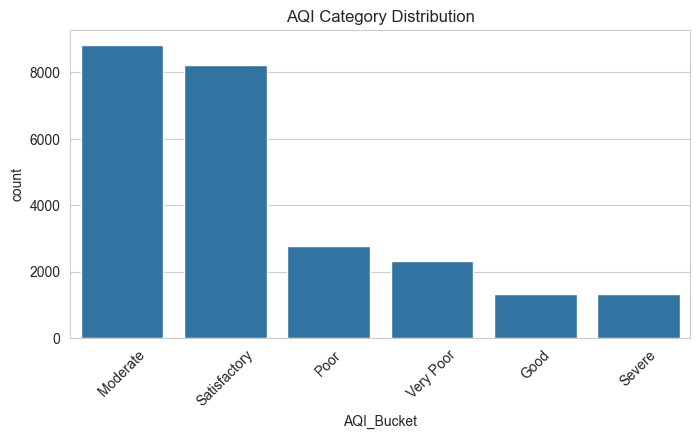

In [12]:
plt.figure(figsize=(8,4))
order = df['AQI_Bucket'].value_counts().index
sns.countplot(x='AQI_Bucket', data=df, order=order)
plt.xticks(rotation=45)
plt.title("AQI Category Distribution")
plt.savefig(FIG_DIR + "aqi_bucket_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


## 5. Univariate Analysis - each pollutent
 

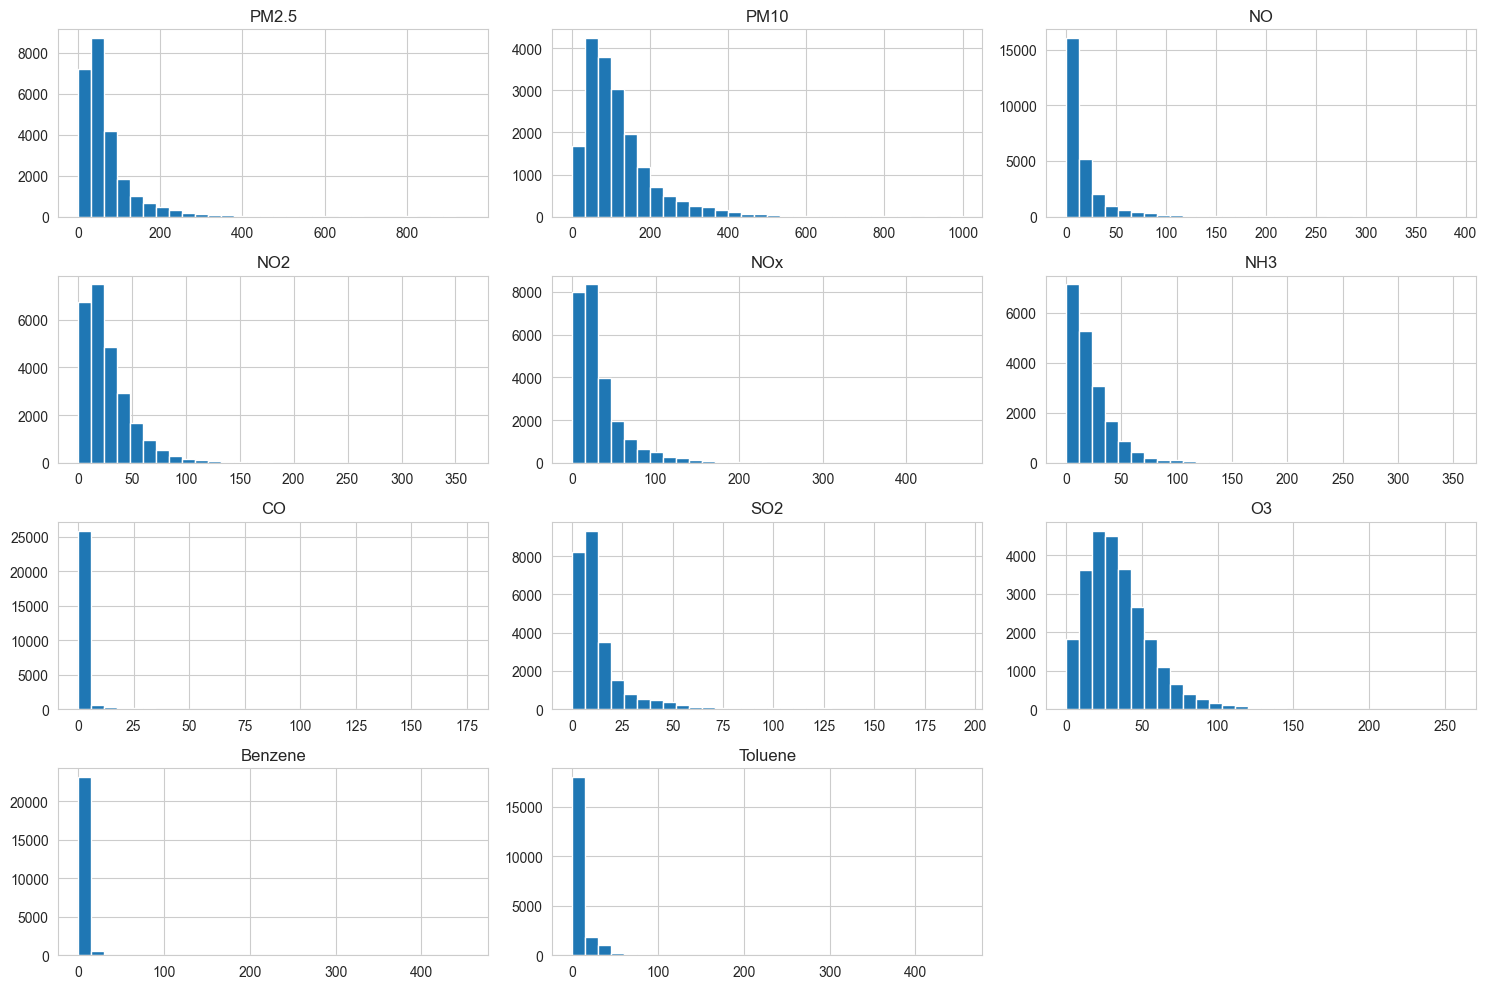

In [13]:
pollutant_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene']

df[pollutant_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.savefig(FIG_DIR + "pollutant_histograms.png", dpi=150, bbox_inches='tight')
plt.show()


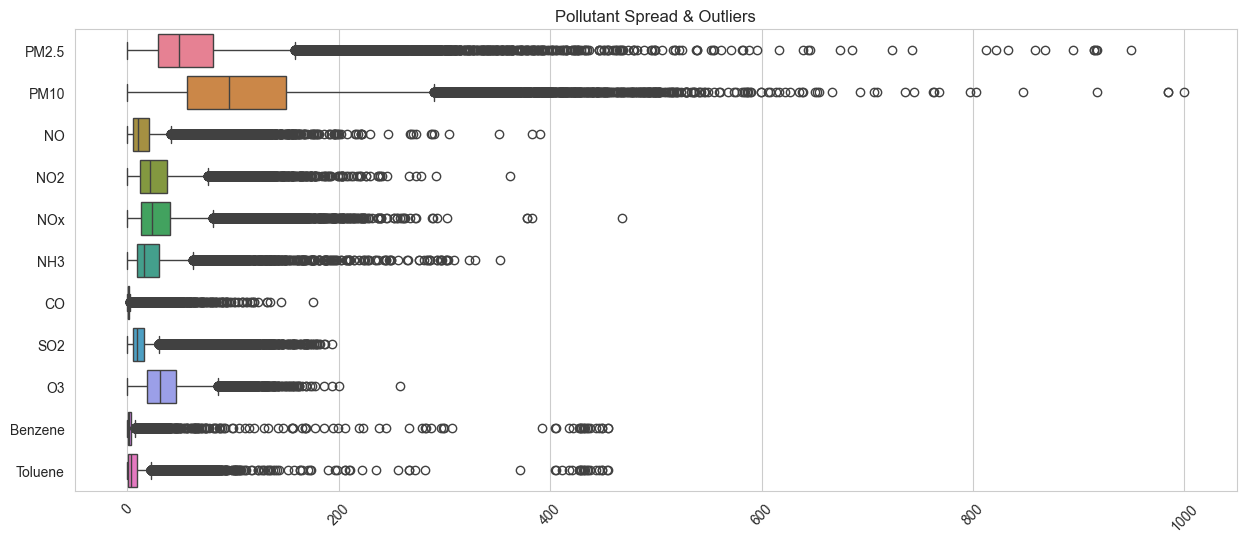

In [14]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df[pollutant_cols], orient='h')
plt.title("Pollutant Spread & Outliers")
plt.xticks(rotation=45)
plt.savefig (FIG_DIR + "pollutant_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation analysis

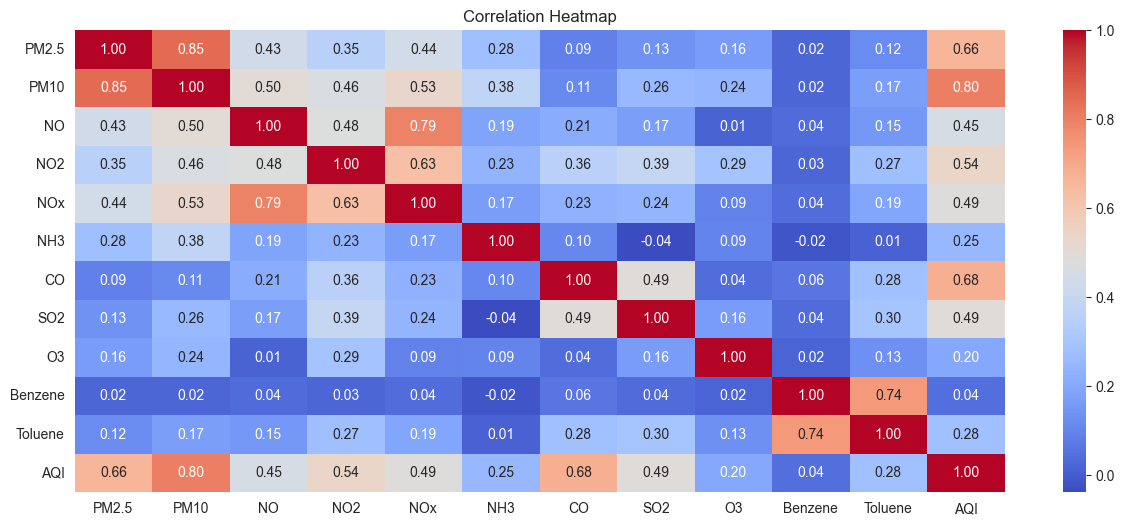

In [15]:
plt.figure(figsize=(15,6))
corr = df[pollutant_cols + ['AQI']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig(FIG_DIR + "correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
corr['AQI'].sort_values(ascending=False)

AQI        1.000000
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Benzene    0.044407
Name: AQI, dtype: float64

## 7. City-wise comparison

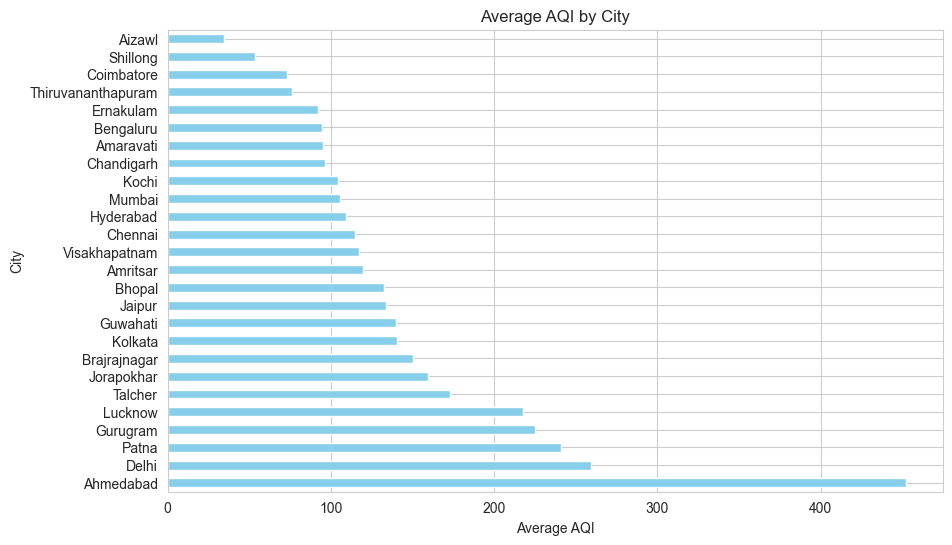

In [17]:
city_avg_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
city_avg_aqi.plot(kind='barh', color='skyblue')  #barh for horizontal bar chart
plt.title("Average AQI by City")
plt.xlabel("Average AQI")
plt.savefig(FIG_DIR + "average_aqi_by_city.png", dpi=150, bbox_inches='tight')
plt.show()

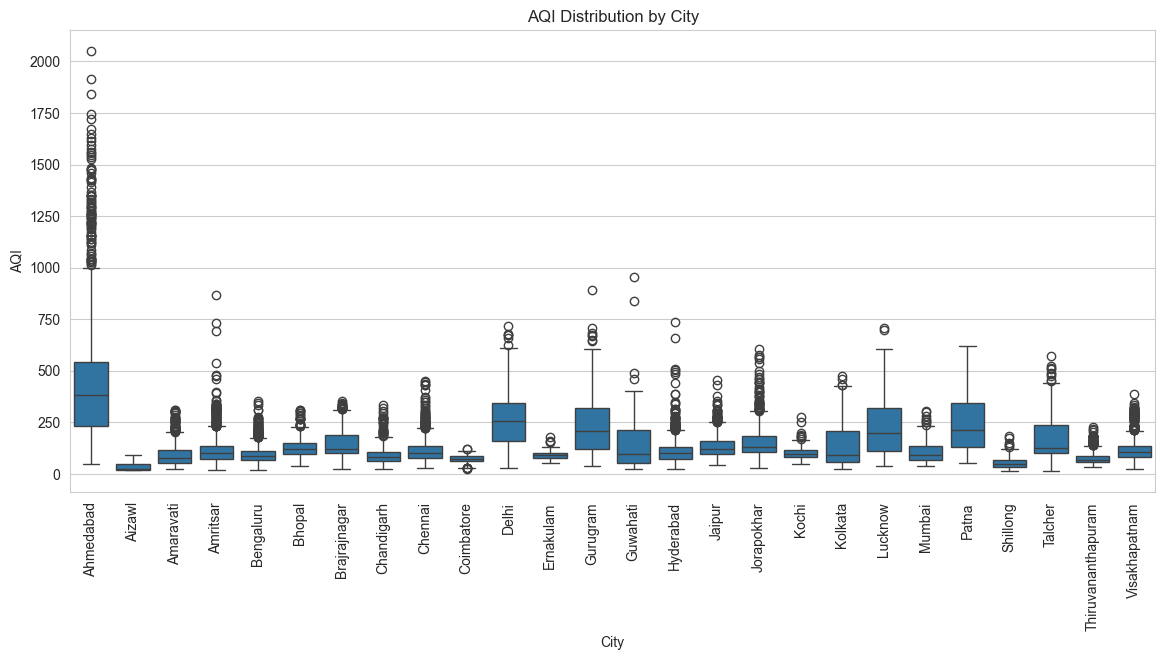

In [18]:
plt.figure(figsize=(14,6))
sns.boxplot(x='City', y='AQI', data=df)
plt.title("AQI Distribution by City")
plt.xlabel("City")
plt.ylabel("AQI")
plt.xticks(rotation=90)
plt.savefig(FIG_DIR + "aqi_distribution_by_city.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Time-based trends (seasonality)

In [19]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month


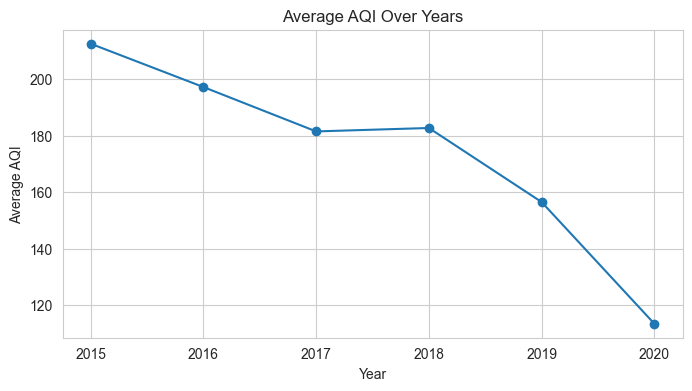

In [20]:
yearly = df.groupby("Year")['AQI'].mean()

plt.figure(figsize=(8,4))
yearly.plot(kind='line', marker='o')
plt.title("Average AQI Over Years")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.savefig(FIG_DIR + "yearly_trend.png", dpi=150, bbox_inches='tight')
plt.show()

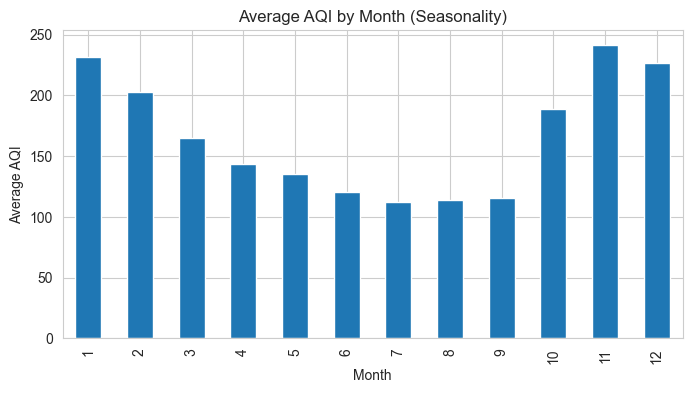

In [21]:
monthly = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(8,4))
monthly.plot(kind='bar')
plt.title("Average AQI by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.savefig(FIG_DIR + "monthly_seasonality.png", dpi=150, bbox_inches='tight')
plt.show()


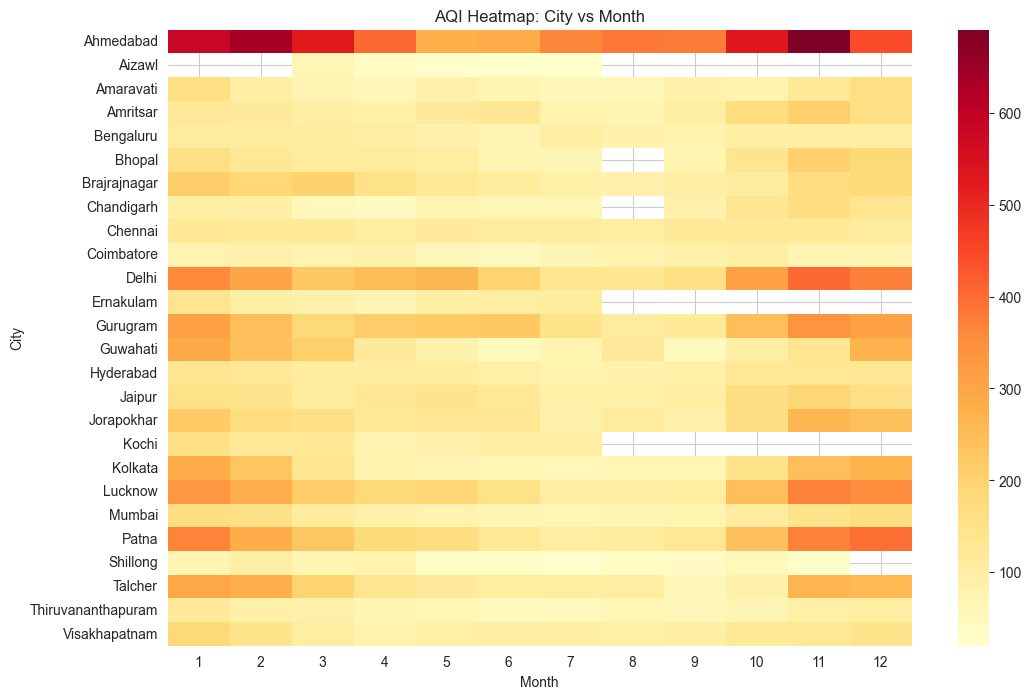

In [22]:
pivot = df.pivot_table(values='AQI', index='City', columns='Month', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title("AQI Heatmap: City vs Month")
plt.savefig(FIG_DIR + "city_vs_month_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


## 9. Bivariate analysis — pollutant vs AQI

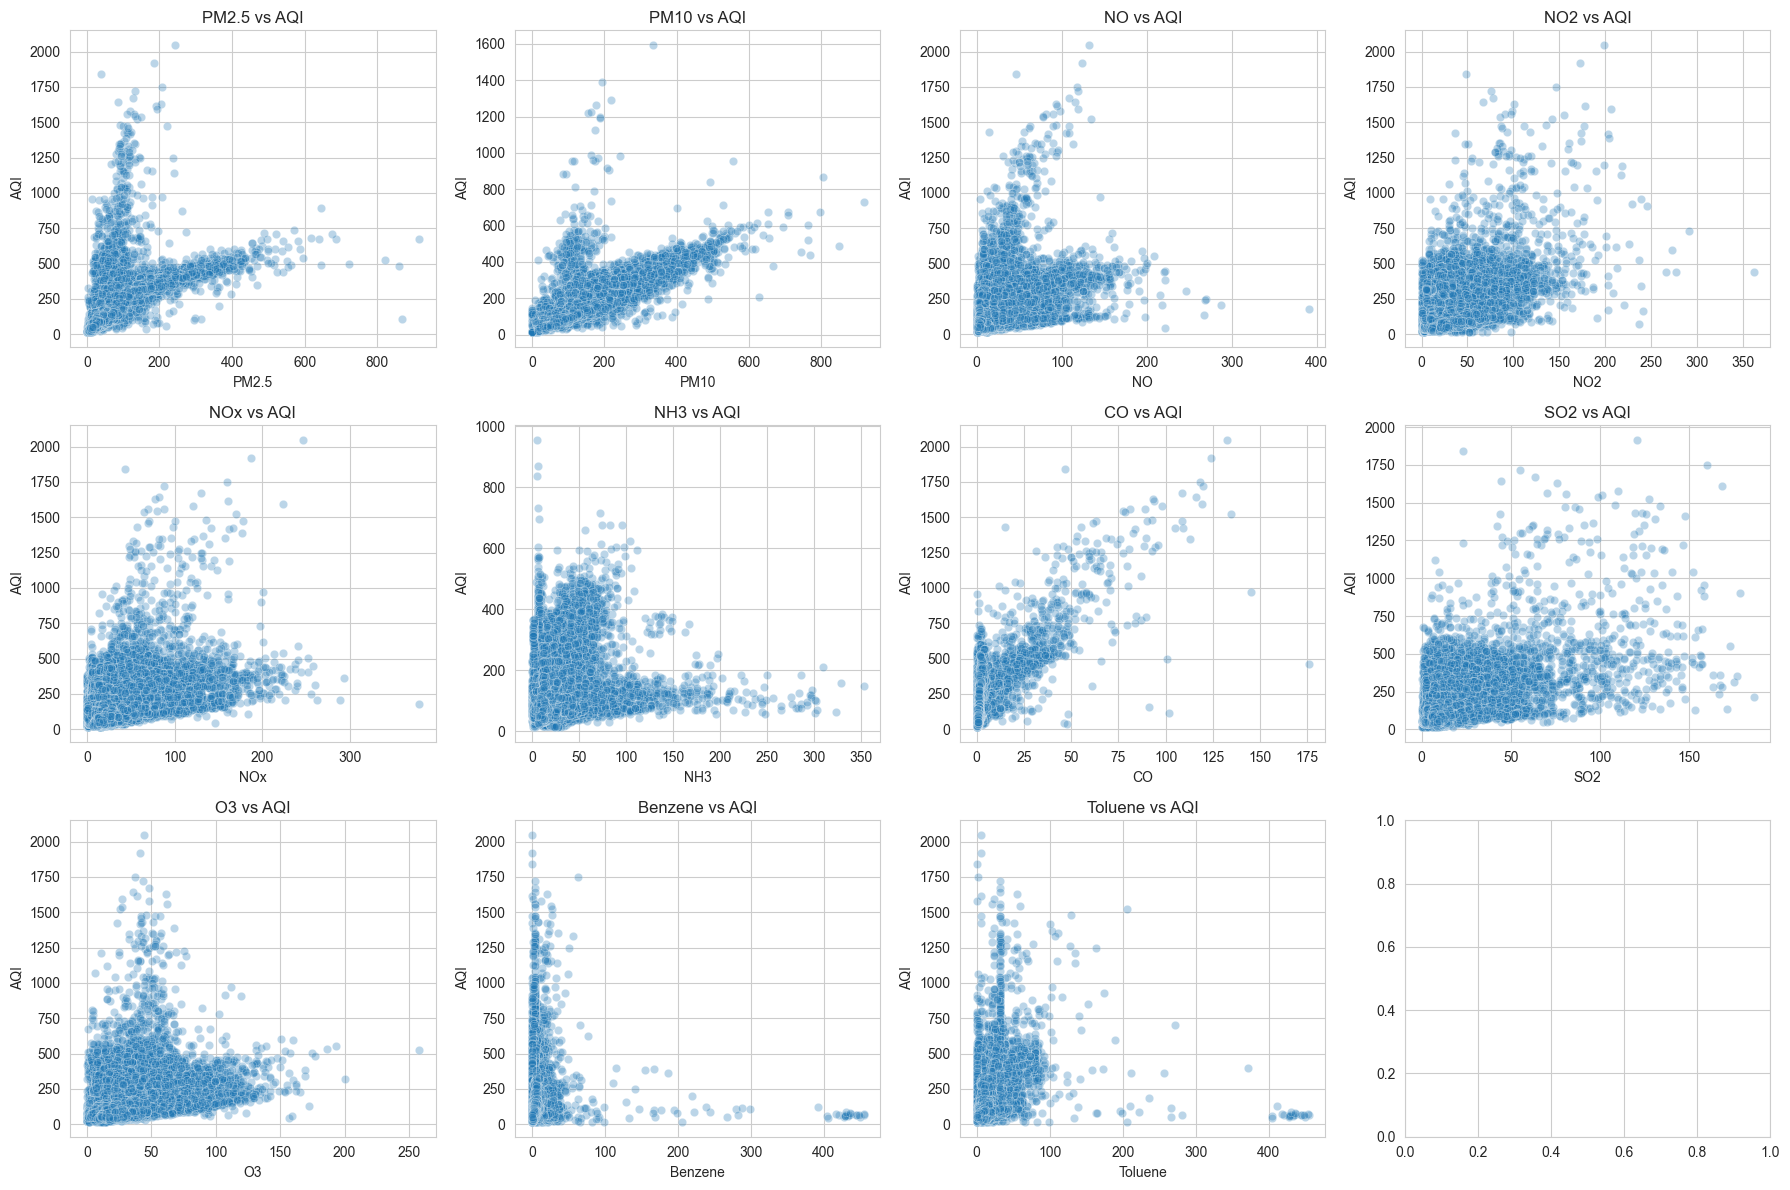

In [23]:
fig, axes = plt.subplots(3, 4, figsize=(18,12))
for i, col in enumerate(pollutant_cols):
    sns.scatterplot(x=df[col], y=df['AQI'], ax=axes[i//4, i%4], alpha=0.3)
    axes[i//4, i%4].set_title(f"{col} vs AQI")
plt.tight_layout()
plt.savefig(FIG_DIR + "pollutant_vs_aqi_scatter.png", dpi=150, bbox_inches='tight')
plt.show()


## 10. Pairplot (sampled — full pairplot on all pollutants is slow)

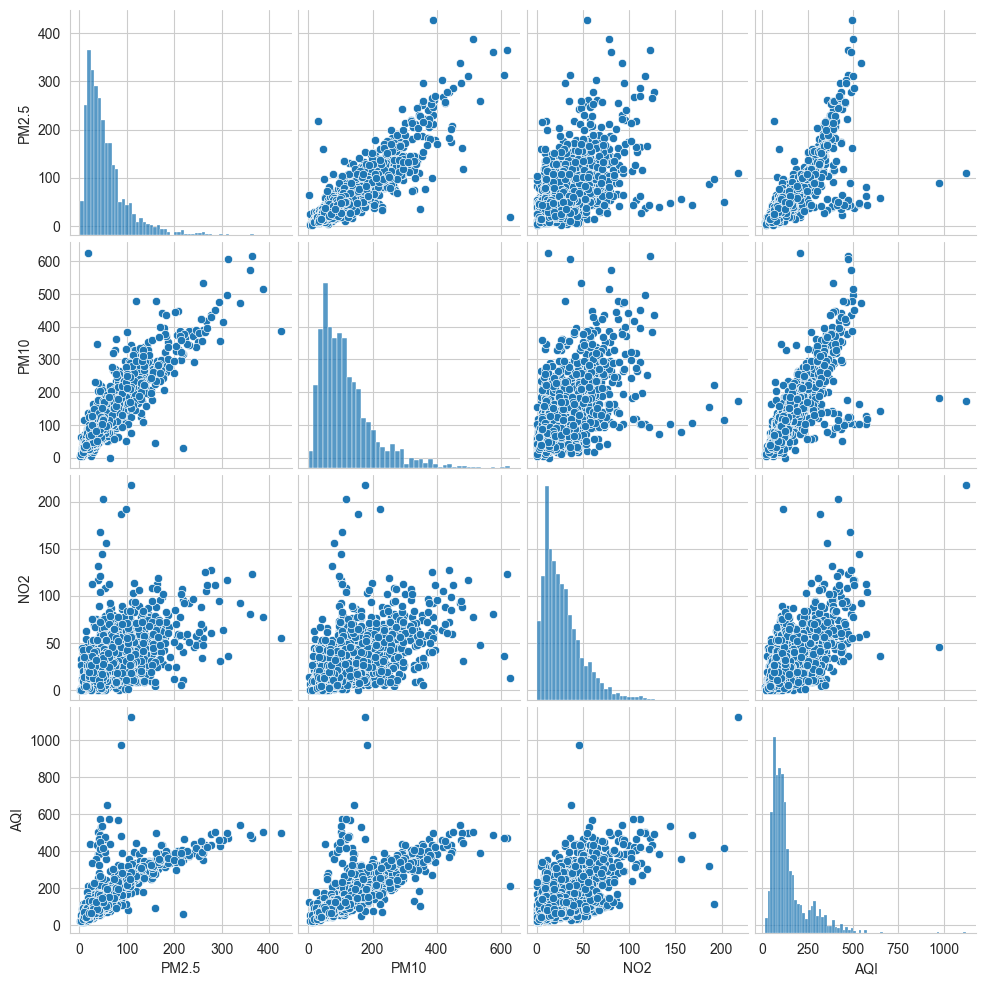

In [24]:
sns.pairplot(df[['PM2.5','PM10','NO2','AQI']].dropna().sample(2000, random_state=42))
plt.savefig(FIG_DIR + "pairplot_sample.png", dpi=150, bbox_inches='tight')
plt.show()


## 11. Key takeaways

Fill this in after reviewing the charts above — typical findings to look for:

- Which pollutant correlates most strongly with AQI (usually PM2.5 / PM10)
- Which cities have the worst average AQI
- Which months/season show the sharpest spikes (commonly winter in North India)
- Roughly how imbalanced the `AQI_Bucket` classes are (relevant for later modeling)
- Any pollutants with unusually high outlier counts (candidates for capping in preprocessing)